# Drifing Gaussian

## Imports

In [1]:
import dolfinx as dx
import dolfinx.fem.petsc
import dolfinx.plot as dxp
from mpi4py import MPI
import numpy as np
from petsc4py import PETSc
import pyvista as pv
import ufl

## Setup

In [2]:
pv.set_jupyter_backend('static')
plotter = pv.Plotter()

## Parameters

In [3]:
h0 = 1.0 # Constant height
u0 = 1.0 # Constant rightward flow
v0 = 0.0 # No vertical flow
nx = 10 # Cell resolution
dt = 0.01 # Time step
nt = 100
write_every = 1 # Only every nth frame
plot_speedup = 1

In [4]:
# Initial condition
x0 = 0.5
y0 = 0.5
r0 = 0.1
def iota0(x):
    return np.exp(-((x[0] - x0) ** 2 + (x[1] - y0) ** 2)/ r0 ** 2)

## Mesh

In [5]:
# Define a simple
domain = dx.mesh.create_unit_square(MPI.COMM_WORLD, nx, nx, cell_type=dx.mesh.CellType.triangle)

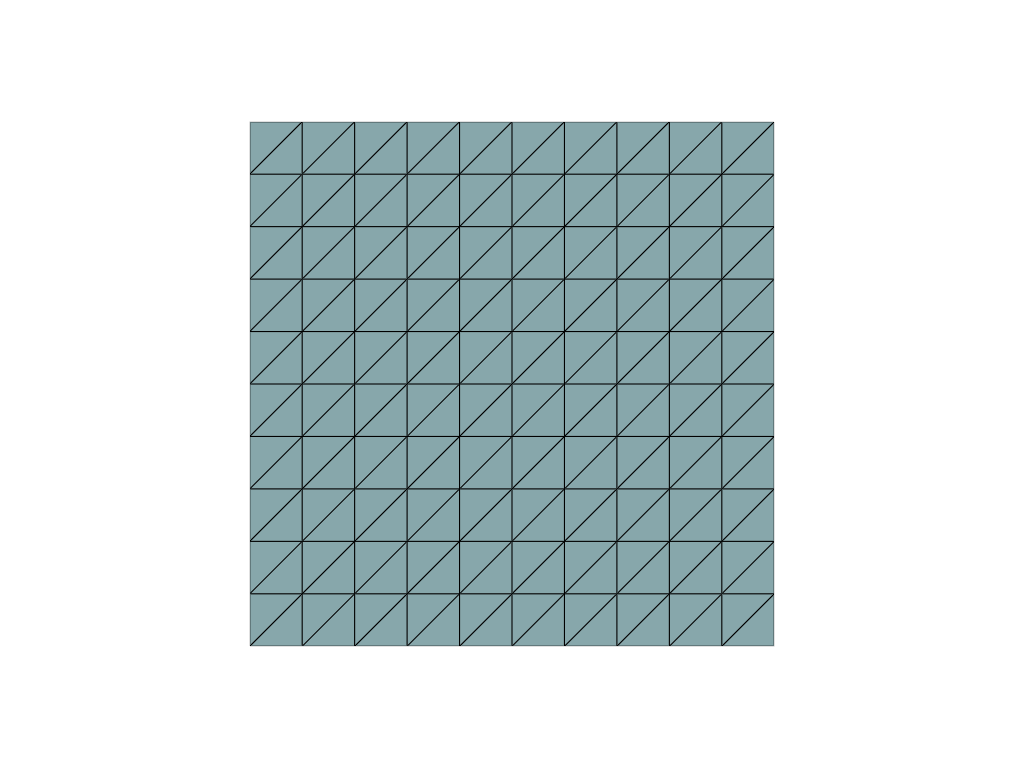

In [6]:
topology, cell_types, geometry = dxp.vtk_mesh(domain, domain.topology.dim)
grid = pv.UnstructuredGrid(topology, cell_types, geometry)
plotter.add_mesh(grid, show_edges=True, color="lightblue")
plotter.view_xy()
plotter.show()

## FEM Formulation

In [7]:
# Linear DG space
V = dx.fem.functionspace(domain, ('Discontinuous Lagrange', 1))

In [8]:
# Trial and test functions
dq_dt = ufl.TrialFunction(V) # Derivative of q
q = dx.fem.Function(V) # Conserved quantity iota = c * h
phi = ufl.TestFunction(V) # Scalar test function

In [9]:
# FEM functions for solution loop
diota_dt = dx.fem.Function(V) # Not to be confused with trial function
diota_dt_vec = dx.la.petsc.create_vector_wrap(diota_dt.x) # For PETSc solve
iota = dx.fem.Function(V) # Conserved quantity iota = c * h
iota.interpolate(iota0)

In [10]:
# Additional functions
h = dx.fem.Constant(domain, h0)
v = dx.fem.Constant(domain, (u0, v0))
n = ufl.FacetNormal(domain)

In [11]:
# Hyperbolic formulation
def F(U):
    """Flux function F(U)"""
    return U * v
def J(U):
    """Flux Jacobian dF/dU(U)"""
    return v

In [12]:
# Flux treatments
def fluxn_upwind(F, J, U, n):
    """Upwind flux treatment for a scalar law.

    The value of the flux at the interface is chosen to be either F(U+) or
    F(U-), depending on the characteristic speeds. If the characteristic is
    going from element + to -, the flux from + is used, and vice versa. If
    the two elements' characteristics "disagree," an average is used instead.
    
    Args:
        F (callable): A single-argument Python function that returns a UFL vector given a scalar state.
        J (callable): A single-argument Python function that returns dF/dU given a scalar state.
        U (ufl.Coefficient or ufl.Argument): The scalar state variable.
        n (ufl.FacetNormal): The normal at the cell interface.

    Returns:
        ufl.Conditional: The upwinded flux projected on the normal.
    """

    # Project onto outward normal of + to get speeds
    J_plus_n_plus = ufl.dot(J(U('+')), n('+')) # Characteristic speed at +
    J_minus_n_plus = ufl.dot(J(U('-')), n('+')) # Characteristic speed at -, using +'s normal

    # Determine whether wave is entering or leaving +
    leaving_plus = ufl.and_condition(J_plus_n_plus > 0.0, J_minus_n_plus > 0.0)
    entering_plus = ufl.and_condition(J_plus_n_plus < 0.0, J_minus_n_plus < 0.0)

    # Choose appropriate flux from source element
    F_plus = F(U('+'))
    F_minus = F(U('-'))
    return ufl.dot(ufl.conditional(
        leaving_plus,
        F_plus,
        ufl.conditional(
            entering_plus,
            F_minus,
            0.5 * (F_plus + F_minus)
        )
    ), n('+'))

In [13]:
def fluxn_llf(F, J, U, n):
    """Local Lax-Friedrichs treatment for a scalar law.

    This is 0.5 * (F(U+) + F(U-)) + 0.5 * lambda * (U+ - U-)

    Args:
        F (callable): A single-argument Python function that returns a UFL vector given a scalar state.
        J (callable): A single-argument Python function that returns dF/dU given a scalar state.
        U (ufl.Coefficient or ufl.Argument): The scalar state variable.
        n (ufl.FacetNormal): The normal at the cell interface.

    Returns:
        ufl.Conditional: The Local Lax-Friedrichs flux projected on the normal.
    """

    # Project onto outward normal of + to get speeds
    abs_J_plus_n = abs(ufl.dot(J(U('+')), n('+'))) # Characteristic speed at +
    abs_J_minus_n = abs(ufl.dot(J(U('-')), n('+'))) # Characteristic speed at -
    lam = ufl.max_value(abs_J_plus_n, abs_J_minus_n)

    # Get fluxes from both sides
    F_plus = F(U('+'))
    F_minus = F(U('-'))

    # Return LLF formula
    return 0.5 * ufl.dot(F_plus + F_minus, n('+')) + 0.5 * lam * (U('+') - U('-'))

In [14]:
# Manual upwinding
# vn = ufl.dot(v, n)
# iota_upwind = ufl.conditional(vn('+') > 0.0, iota('+'), iota('-')) # Upwind
# F_boundary = F(iota_upwind)

In [15]:
# Use a particular flux treatment
F_interior = F(q)
Fn_boundary = fluxn_llf(F, J, q, n)

In [16]:
# UFL form
# General form is dU/dt * phi + B(iota, phi) = 0
M_form = dx.fem.form(dq_dt * phi * ufl.dx) # Mass matrix
B_interior = -ufl.dot(F_interior, ufl.grad(phi)) * ufl.dx
B_interior_facets = Fn_boundary * ufl.jump(phi) * ufl.dS
vn = ufl.dot(v, n)
B_boundary = ufl.conditional(vn > 0.0, q, dx.fem.Constant(domain, 0.0)) * vn * phi * ufl.ds
B_form = dx.fem.form(ufl.replace(-B_interior - B_interior_facets - B_boundary, {q: iota})) # For explicit method

## Assembly

In [17]:
# Assemble mass matrix
M = dx.fem.petsc.assemble_matrix(M_form)
M.assemble()

In [18]:
# Set up solver
# Serial only
M_solver = PETSc.KSP().create(domain.comm)
M_solver.setOperators(M)
M_solver.setType(PETSc.KSP.Type.PREONLY)
M_solver.getPC().setType(PETSc.PC.Type.LU)
M_solver.setFromOptions() # Allows command-line PETSc options to override the above
M_solver.setUp()

In [19]:
# Create RHS
b = dx.fem.petsc.create_vector(V)

## Solution

In [20]:
# Set up PyVista plotting
topology, cell_types, geometry = dxp.vtk_mesh(V)
grid = pv.UnstructuredGrid(topology, cell_types, geometry)
grid.point_data['iota'] = np.asarray(iota.x.array.real).copy()
plotter = pv.Plotter()
plotter.add_mesh(
    grid,
    scalars='iota',
    cmap='jet',
    clim=[0.0, 1.0],
    show_edges=False
)
plotter.view_xy()
# plotter.show()
plotter.open_gif('drifting_gaussian.gif', fps=(plot_speedup * nt / write_every))

In [21]:
t = 0.0
for step in range(nt):
    # print(f'Step {step:04d} of {nt:04d}')
    
    # Update time
    t = step * dt

    # Update arrays
    b.set(0.0)
    dx.fem.petsc.assemble_vector(b, B_form)
    b.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE)

    # Solve for time derivative, M * iota_dot = b
    M_solver.solve(b, diota_dt_vec)

    # Update only owned DOFs
    n_owned = (
        V.dofmap.index_map.size_local
        * V.dofmap.index_map_bs
    )

    # Forward Euler update
    iota.x.array[:n_owned] += dt * diota_dt.x.array[:n_owned] # Only n_owned for parallel
    iota.x.scatter_forward()

    # Write output to GIF
    if step % write_every == 0:
        grid.point_data['iota'] = np.asarray(iota.x.array.real).copy() # Make sure plotter is updated
        plotter.write_frame()

## Visualization

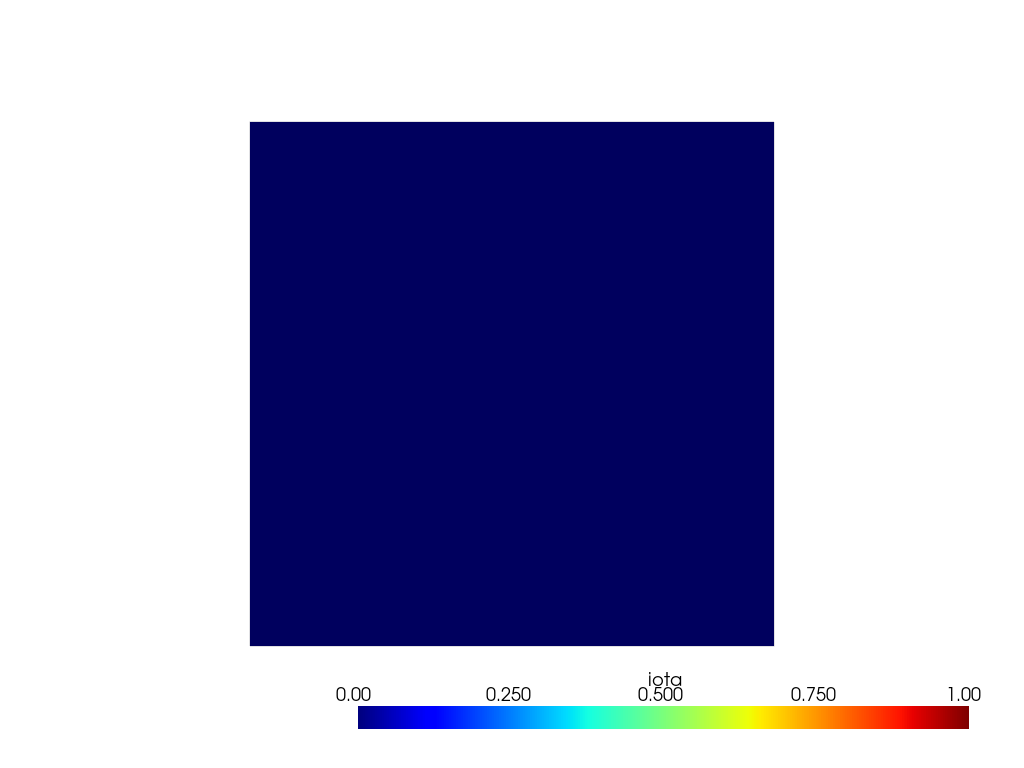

In [22]:
# See end result
plotter.show()

In [23]:
# Close and save file
plotter.close()